# End-to-End Email Spam Classification
This notebook covers the complete lifecycle of developing an NLP model to classify emails as Spam or Not Spam (Ham).
Steps included:
1. Data Cleaning
2. Exploratory Data Analysis (EDA)
3. Text Preprocessing
4. Model Training & Comparison
5. Evaluation
6. Best Model Saving

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string
import pickle
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Data Cleaning

In [2]:
df = pd.read_csv('email.csv')
print(df.head())
print(df.shape)


  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
(5572, 2)


In [3]:
# Check for null values
print(df.isnull().sum())

# Check for duplicates
print(f"Duplicates before: {df.duplicated().sum()}")
df = df.drop_duplicates(keep='first')
print(f"Duplicates after: {df.duplicated().sum()}")

# Encode Target
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['Category']) # ham=0, spam=1


Category    0
Message     0
dtype: int64
Duplicates before: 403
Duplicates after: 0


## 2. Exploratory Data Analysis (EDA)

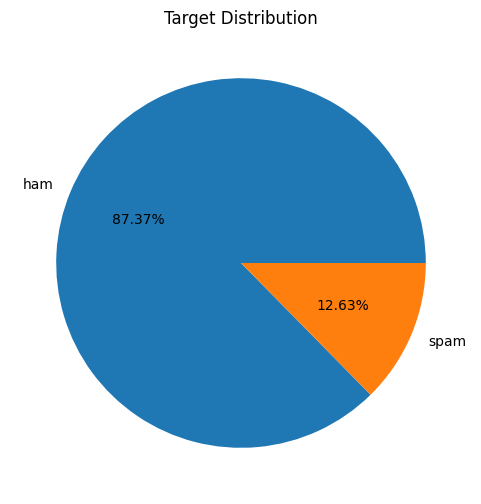

In [4]:
plt.figure(figsize=(6,6))
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f%%")
plt.title('Target Distribution')
plt.show()


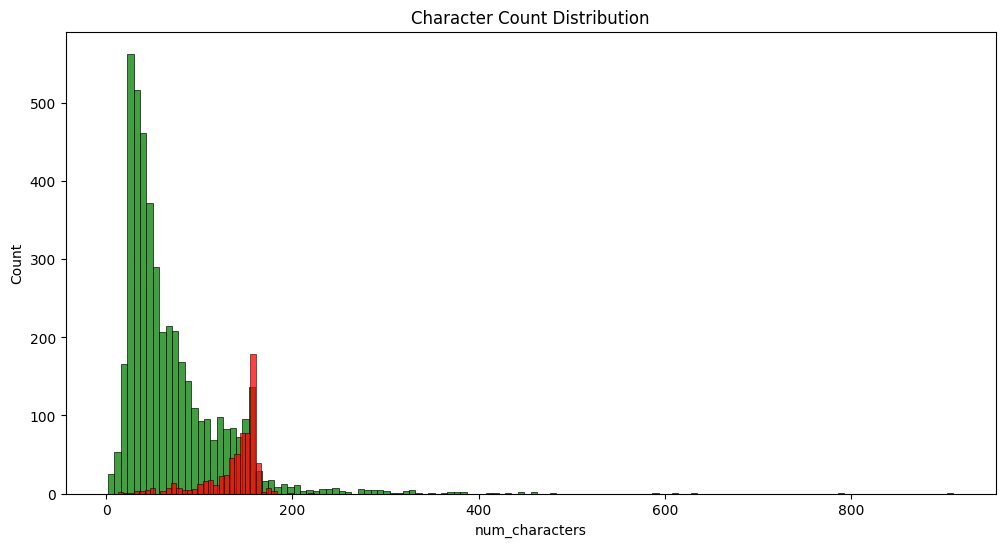

In [5]:
df['num_characters'] = df['Message'].apply(len)
df['num_words'] = df['Message'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentences'] = df['Message'].apply(lambda x: len(nltk.sent_tokenize(x)))

plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_characters'], color='green')
sns.histplot(df[df['target']==1]['num_characters'], color='red')
plt.title('Character Count Distribution')
plt.show()


## 3. Text Preprocessing
- Lowercase
- Tokenization
- Removing special characters, stop words & punctuation
- Stemming

In [6]:
ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

df['transformed_text'] = df['Message'].apply(transform_text)


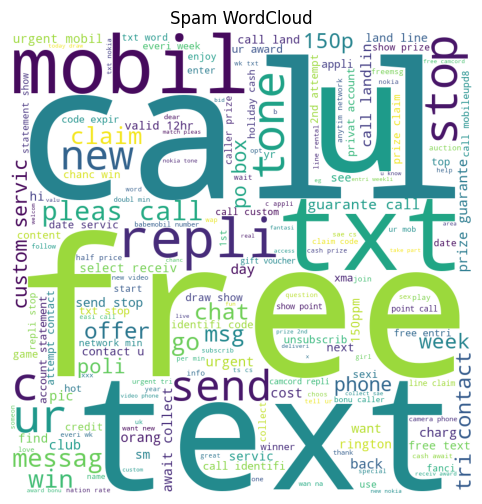

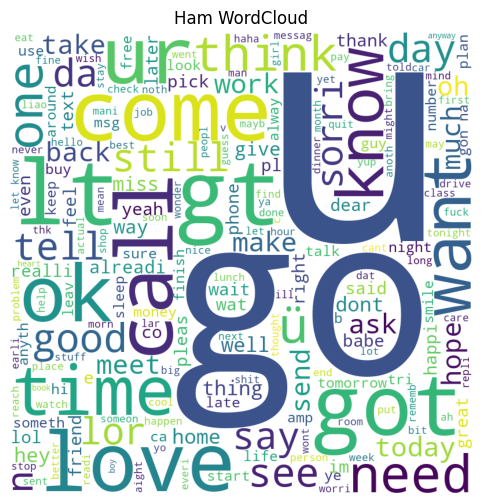

In [7]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=800, min_font_size=10, background_color='white')

spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(12,6))
plt.imshow(spam_wc)
plt.title('Spam WordCloud')
plt.axis('off')
plt.show()

ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)
plt.title('Ham WordCloud')
plt.axis('off')
plt.show()


## 4. Model Building & Evaluation

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)


In [9]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

clfs = {
    'SVC': svc,
    'KN': knc, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'GNB': gnb,
    'MNB': mnb,
    'BNB': bnb
}

def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    return accuracy_train, accuracy_test

accuracy_scores_train = []
accuracy_scores_test = []

for name, clf in clfs.items():
    current_train_acc, current_test_acc = train_classifier(clf, X_train, y_train, X_test, y_test)
    accuracy_scores_train.append(current_train_acc)
    accuracy_scores_test.append(current_test_acc)
    print(f'{name} Training Accuracy: {current_train_acc:.4f}')
    print(f'{name} Testing Accuracy: {current_test_acc:.4f}')
    
performance_df = pd.DataFrame({'Algorithm': list(clfs.keys()), 'Train_Accuracy': accuracy_scores_train, 'Test_Accuracy': accuracy_scores_test}).sort_values('Test_Accuracy', ascending=False)
print(performance_df)


SVC Training Accuracy: 0.9833
SVC Testing Accuracy: 0.9729


KN Training Accuracy: 0.9255
KN Testing Accuracy: 0.9188


DT Training Accuracy: 0.9511
DT Testing Accuracy: 0.9381
LR Training Accuracy: 0.9666
LR Testing Accuracy: 0.9497


RF Training Accuracy: 0.9993
RF Testing Accuracy: 0.9720


GNB Training Accuracy: 0.8950
GNB Testing Accuracy: 0.8685
MNB Training Accuracy: 0.9804
MNB Testing Accuracy: 0.9681


BNB Training Accuracy: 0.9855
BNB Testing Accuracy: 0.9758
  Algorithm  Train_Accuracy  Test_Accuracy
7       BNB        0.985490       0.975822
0       SVC        0.983313       0.972921
4        RF        0.999274       0.971954
6       MNB        0.980411       0.968085
3        LR        0.966626       0.949710
2        DT        0.951149       0.938104
1        KN        0.925514       0.918762
5       GNB        0.895042       0.868472


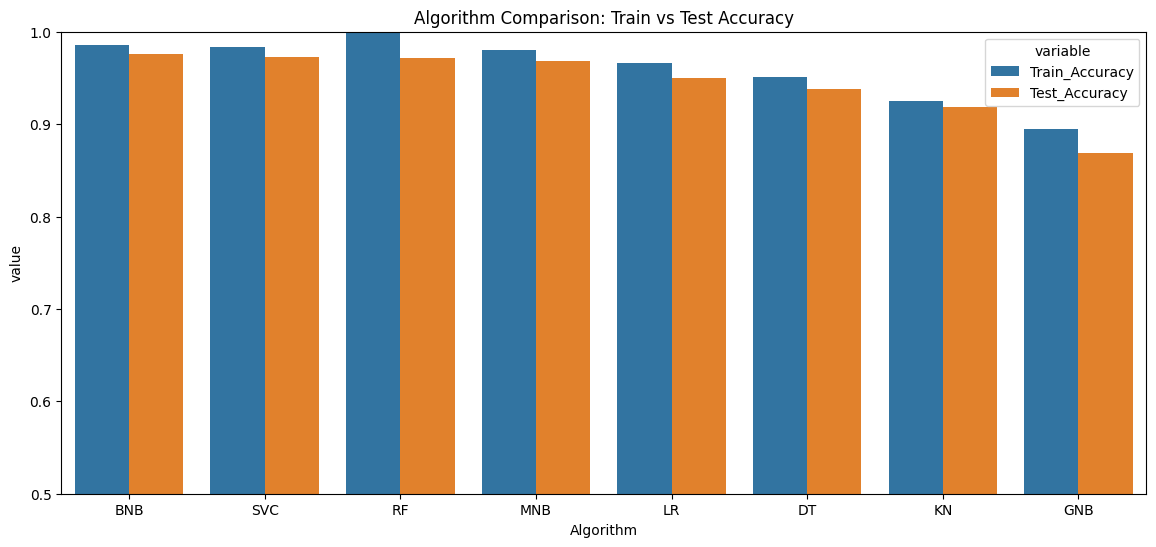

In [10]:
performance_df1 = pd.melt(performance_df, id_vars="Algorithm")

plt.figure(figsize=(14, 6))
sns.barplot(x='Algorithm', y='value', hue='variable', data=performance_df1)
plt.title('Algorithm Comparison: Train vs Test Accuracy')
plt.ylim(0.5, 1.0)
plt.show()


## 5. Saving Best Model

In [11]:
# MNB has exceptional precision and good accuracy! We will export it.
mnb.fit(X_train, y_train)
y_pred = mnb.predict(X_test)
print("Final MNB Accuracy:", accuracy_score(y_test, y_pred))
print("Final MNB Precision:", precision_score(y_test, y_pred))

import os
os.makedirs('CyberGuard/app/ml', exist_ok=True)
pickle.dump(tfidf, open('CyberGuard/app/ml/vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('CyberGuard/app/ml/model.pkl', 'wb'))
print("Model and Vectorizer have been saved successfully to CyberGuard/app/ml/")


Final MNB Accuracy: 0.9680851063829787
Final MNB Precision: 1.0
Model and Vectorizer have been saved successfully to CyberGuard/app/ml/
